# Beyond Pairwise: Dependence, Structure, and the Arrow of Information

> *"The most important questions in science are often not 'Are X and Y related?' but rather 'How much structure do these variables share?' and 'Which way does the information flow?'"*

In the [first notebook](Divergence.ipynb), we learned that **mutual information** captures *all* statistical dependence between two variables — linear and nonlinear alike. But the world rarely comes in pairs. A cell's fate depends on thousands of genes. A stock price responds to an entire market. A patient's outcome reflects dozens of biomarkers interacting at once.

This notebook explores measures that go beyond the pairwise lens:

| Measure | Question it answers | Inventor(s) |
|---------|--------------------|--------------|
| **Total Correlation** | How much *total redundancy* exists among $d$ variables? | Watanabe (1960) |
| **Normalized MI** | How can we compare MI values on a common scale? | Strehl & Ghosh (2002) |
| **Variation of Information** | How *different* are two clusterings, measured as a true metric? | Meilă (2003) |
| **Transfer Entropy** | Does knowing the past of $X$ help predict the future of $Y$? | Schreiber (2000) |

We progress from **static structure** (how variables relate right now) to **dynamic causality** (how information flows through time) — a journey that spans four decades of research across physics, computer science, and statistics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from divergence import (
    total_correlation,
    normalized_mutual_information,
    variation_of_information,
    transfer_entropy,
    knn_entropy,
    ksg_mutual_information,
    discrete_entropy,
    discrete_mutual_information,
)

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

np.random.seed(42)

from pathlib import Path
FIGURES_DIR = Path('figures/dependence_and_causality')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

---

## 1. Total Correlation: The Redundancy Among Many

### The question that started it all

In 1960, **Satosi Watanabe** — a Japanese physicist and philosopher of science working at IBM Research — published a paper in the *IBM Journal of Research and Development* that asked a question so natural it seems obvious in hindsight: if mutual information measures the shared information between *two* variables, what is the right generalization to *many*?

<!-- Portrait: Satosi Watanabe (1910–1993) — physicist, philosopher, pioneer of pattern recognition -->

Watanabe was no ordinary researcher. Trained in quantum mechanics under Werner Heisenberg in Leipzig, he spent decades thinking about the deepest questions in the philosophy of science — what it means to "know" something, and how to formalize the intuition that structured data contains less information than random noise. His answer was the **total correlation**, sometimes called **multi-information**:

$$
\mathrm{TC}(X_1, \ldots, X_d) = \sum_{i=1}^{d} H(X_i) - H(X_1, \ldots, X_d)
$$

The intuition is beautiful: if the variables were completely independent, the joint entropy would equal the sum of marginals. Any *structure* — any correlations, any shared patterns — reduces the joint entropy below this maximum. The total correlation measures exactly that gap: the **total amount of redundancy** among $d$ variables.

**Key properties:**
- $\mathrm{TC} \geq 0$, with equality if and only if all variables are mutually independent
- For $d = 2$, total correlation reduces exactly to mutual information $I(X_1; X_2)$
- Measured in nats (or bits, depending on the log base)

### Independent variables: no redundancy

In [2]:
n = 5000

# Three independent standard normals
X_indep = np.column_stack([
    np.random.randn(n),
    np.random.randn(n),
    np.random.randn(n),
])

tc_indep = total_correlation(X_indep, estimator='knn')
print(f'Total correlation (3 independent normals): {tc_indep:.4f} nats')
print(f'Expected: ≈ 0.0 (no shared structure)')

Total correlation (3 independent normals): 0.0290 nats
Expected: ≈ 0.0 (no shared structure)


### Correlated variables: structure emerges

In [3]:
# Create 3 correlated variables via a common factor
# X1 = Z + noise, X2 = Z + noise, X3 = Z + noise
Z = np.random.randn(n)
noise_scale = 0.5
X_corr = np.column_stack([
    Z + noise_scale * np.random.randn(n),
    Z + noise_scale * np.random.randn(n),
    Z + noise_scale * np.random.randn(n),
])

tc_corr = total_correlation(X_corr, estimator='knn')
print(f'Total correlation (3 variables sharing a common factor): {tc_corr:.4f} nats')
print(f'The shared factor Z creates substantial redundancy among all three variables.')

Total correlation (3 variables sharing a common factor): 1.1435 nats
The shared factor Z creates substantial redundancy among all three variables.


### The bridge to mutual information

For $d = 2$, total correlation and mutual information are the same quantity. Let's verify this — it's a satisfying consistency check that connects Watanabe's generalization back to Shannon's original framework:

In [4]:
# Bivariate normal with rho = 0.7
rho = 0.7
x = np.random.randn(n)
y = rho * x + np.sqrt(1 - rho**2) * np.random.randn(n)

tc_2d = total_correlation(np.column_stack([x, y]), estimator='knn')
mi_2d = ksg_mutual_information(x, y)

# Analytical MI for bivariate normal
mi_analytical = -0.5 * np.log(1 - rho**2)

print(f'Total correlation (2 vars):  {tc_2d:.4f} nats')
print(f'Mutual information (KSG):    {mi_2d:.4f} nats')
print(f'Analytical MI (ρ={rho}):     {mi_analytical:.4f} nats')
print(f'\nTC and MI agree — Watanabe\'s measure generalizes Shannon\'s.')

Total correlation (2 vars):  0.3273 nats
Mutual information (KSG):    0.3121 nats
Analytical MI (ρ=0.7):     0.3367 nats

TC and MI agree — Watanabe's measure generalizes Shannon's.


### Visualizing the redundancy

Total correlation is the gap between the "independent world" (sum of marginals) and reality (joint entropy). Let's see this visually:

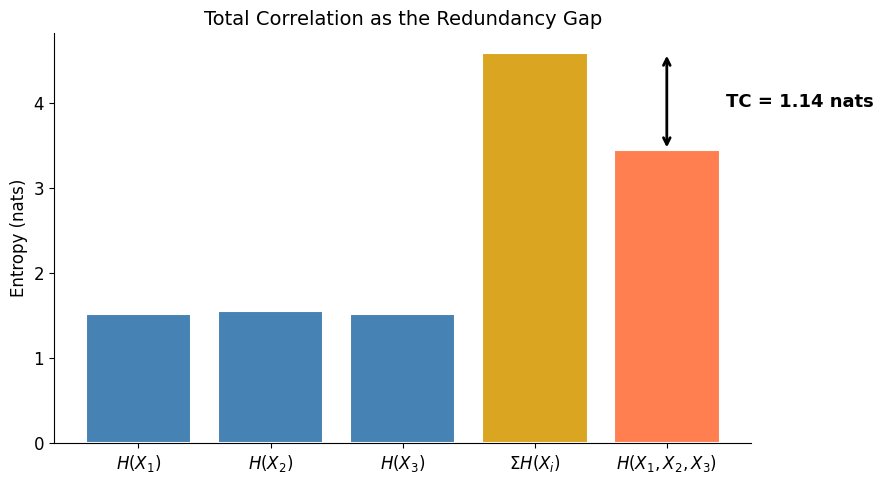

In [5]:
# Compute individual and joint entropies for the correlated 3-variable case
h_marginals = [knn_entropy(X_corr[:, i]) for i in range(3)]
h_joint = knn_entropy(X_corr)
h_sum = sum(h_marginals)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    ['$H(X_1)$', '$H(X_2)$', '$H(X_3)$', '$\\Sigma H(X_i)$', '$H(X_1,X_2,X_3)$'],
    h_marginals + [h_sum, h_joint],
    color=['steelblue', 'steelblue', 'steelblue', 'goldenrod', 'coral'],
    edgecolor='white', linewidth=1.5,
)

# Annotate the TC gap
ax.annotate(
    '', xy=(4, h_joint), xytext=(4, h_sum),
    arrowprops=dict(arrowstyle='<->', color='black', lw=2),
)
ax.text(
    4.45, (h_sum + h_joint) / 2, f'TC = {tc_corr:.2f} nats',
    fontsize=13, fontweight='bold', va='center',
)

ax.set_ylabel('Entropy (nats)')
ax.set_title('Total Correlation as the Redundancy Gap', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'total_correlation_gap.png', dpi=150, bbox_inches='tight')
plt.show()

The gold bar shows what the joint entropy *would be* if the variables were independent. The coral bar shows what it *actually is*. The difference — that downward arrow — is the total correlation: the total information that is **shared and therefore redundant** across the three variables.

---

## 2. Normalized Mutual Information: Comparing on a Common Scale

### The problem with raw MI

Mutual information has a subtle practical problem: its magnitude depends on the entropy of the marginals. Two highly uncertain variables can have large MI even if their *relative* dependence is weak, while two low-entropy variables may have small MI despite being tightly coupled. This makes it hard to compare MI values across different pairs of variables or across different datasets.

In 2002, **Alexander Strehl** and **Joydeep Ghosh** at the University of Texas at Austin published one of the most influential papers in cluster analysis: *"Cluster Ensembles — A Knowledge Reuse Framework for Combining Multiple Partitions."* Their solution to comparing clusterings was elegant: **normalize** the mutual information.

$$
\mathrm{NMI}(X, Y) = \frac{I(X; Y)}{\mathrm{norm}(H(X), H(Y))}
$$

where the normalization function can take several forms:

| Name | Formula | Properties |
|------|---------|------------|
| Geometric | $\sqrt{H(X) \cdot H(Y)}$ | Most commonly used |
| Arithmetic | $\frac{1}{2}(H(X) + H(Y))$ | Upper-bounded by 1 |
| Maximum | $\max(H(X), H(Y))$ | Conservative |
| Minimum | $\min(H(X), H(Y))$ | Liberal |
| Joint | $H(X, Y)$ | Related to VI |

All normalizations map the result to approximately $[0, 1]$: zero for independent variables, one for perfectly dependent variables.

In [6]:
# Demonstrate NMI: identical discrete labels → NMI = 1
labels = np.random.randint(0, 5, size=n)

nmi_identical = normalized_mutual_information(
    labels, labels.copy(), discrete=True, normalization='geometric'
)
print(f'NMI of identical clusterings: {nmi_identical:.4f} (expected: 1.0)')

# Independent labels → NMI ≈ 0
labels_random = np.random.randint(0, 5, size=n)
nmi_random = normalized_mutual_information(
    labels, labels_random, discrete=True, normalization='geometric'
)
print(f'NMI of independent clusterings: {nmi_random:.4f} (expected: ≈ 0.0)')

NMI of identical clusterings: 1.0000 (expected: 1.0)
NMI of independent clusterings: 0.0008 (expected: ≈ 0.0)


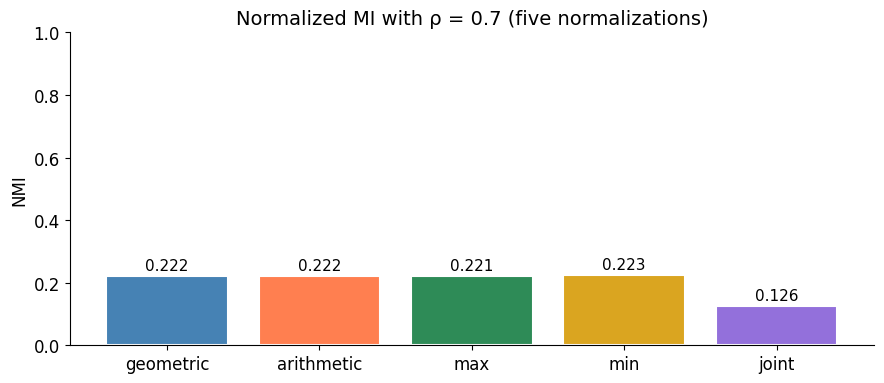

In [7]:
# Compare all five normalizations on the correlated bivariate normal
normalizations = ['geometric', 'arithmetic', 'max', 'min', 'joint']
nmi_values = [
    normalized_mutual_information(x, y, normalization=norm)
    for norm in normalizations
]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['steelblue', 'coral', 'seagreen', 'goldenrod', 'mediumpurple']
ax.bar(normalizations, nmi_values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel('NMI')
ax.set_title(f'Normalized MI with ρ = {rho} (five normalizations)', fontsize=14)
ax.set_ylim(0, 1)
for i, v in enumerate(nmi_values):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'normalized_mi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

All five normalizations agree that there is moderate dependence (consistent with $\rho = 0.7$), but they differ in exactly *how much*. The **minimum** normalization is the most liberal (highest NMI), while **joint** is the most conservative. In practice, **geometric** or **arithmetic** are the most commonly used.

---

## 3. Variation of Information: A True Metric on Partitions

### When symmetry and the triangle inequality matter

In 2003, **Marina Meilă** — a Romanian-American mathematician at the University of Washington — introduced a measure that achieves something remarkable: it is a **true metric** on the space of clusterings.

<!-- Portrait: Marina Meilă — bringing metric geometry to the art of clustering -->

Most information-theoretic quantities are not metrics. KL divergence is asymmetric. Mutual information isn't even a distance (it increases with dependence, not separation). But the variation of information is:

$$
\mathrm{VI}(X, Y) = H(X) + H(Y) - 2\,I(X; Y) = H(X|Y) + H(Y|X)
$$

The second form reveals the intuition: VI measures the information that $X$ has but $Y$ doesn't, plus the information that $Y$ has but $X$ doesn't. It is the **total amount of information that is not shared**.

**Properties that make it special:**
- $\mathrm{VI}(X, Y) \geq 0$, with equality iff $X$ and $Y$ carry the same information
- $\mathrm{VI}(X, Y) = \mathrm{VI}(Y, X)$ — symmetric
- $\mathrm{VI}(X, Z) \leq \mathrm{VI}(X, Y) + \mathrm{VI}(Y, Z)$ — triangle inequality

These three properties make VI a proper distance function, which means it induces a genuine geometry on the space of random variables (or clusterings).

In [8]:
# VI = 0 for identical partitions
vi_identical = variation_of_information(labels, labels.copy(), discrete=True)
print(f'VI of identical clusterings:   {vi_identical:.4f} (expected: 0.0)')

# VI > 0 for independent partitions
vi_indep = variation_of_information(labels, labels_random, discrete=True)
print(f'VI of independent clusterings: {vi_indep:.4f}')

# Verify symmetry
vi_ab = variation_of_information(labels, labels_random, discrete=True)
vi_ba = variation_of_information(labels_random, labels, discrete=True)
print(f'\nVI(A, B) = {vi_ab:.4f}')
print(f'VI(B, A) = {vi_ba:.4f}')
print(f'Symmetric? {np.isclose(vi_ab, vi_ba)}')

VI of identical clusterings:   0.0000 (expected: 0.0)
VI of independent clusterings: 3.2158

VI(A, B) = 3.2158
VI(B, A) = 3.2158
Symmetric? True


In [9]:
# Verify the triangle inequality with three clusterings
labels_c = np.random.randint(0, 5, size=n)

vi_ac = variation_of_information(labels, labels_c, discrete=True)
vi_ab = variation_of_information(labels, labels_random, discrete=True)
vi_bc = variation_of_information(labels_random, labels_c, discrete=True)

print('Triangle inequality check:')
print(f'  VI(A, C)           = {vi_ac:.4f}')
print(f'  VI(A, B) + VI(B, C) = {vi_ab + vi_bc:.4f}')
print(f'  VI(A, C) ≤ VI(A, B) + VI(B, C)? {vi_ac <= vi_ab + vi_bc + 1e-10}')

Triangle inequality check:
  VI(A, C)           = 3.2143
  VI(A, B) + VI(B, C) = 6.4276
  VI(A, C) ≤ VI(A, B) + VI(B, C)? True


### NMI vs. VI: two views of the same coin

NMI and VI answer complementary questions. NMI asks "how much do they *agree*?" (higher is more similar). VI asks "how much do they *disagree*?" (lower is more similar). Let's see how they behave as we gradually corrupt a clustering:

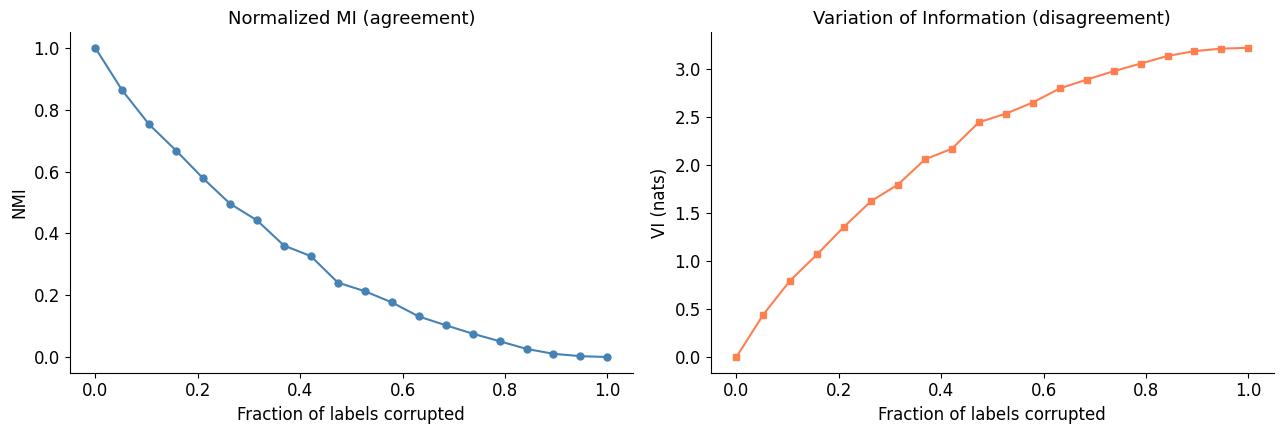

In [10]:
# Gradually corrupt labels by flipping a fraction of them
flip_fractions = np.linspace(0, 1, 20)
nmi_curve = []
vi_curve = []

for frac in flip_fractions:
    corrupted = labels.copy()
    mask = np.random.random(n) < frac
    corrupted[mask] = np.random.randint(0, 5, size=mask.sum())

    nmi_curve.append(normalized_mutual_information(
        labels, corrupted, discrete=True, normalization='geometric'
    ))
    vi_curve.append(variation_of_information(labels, corrupted, discrete=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(flip_fractions, nmi_curve, 'o-', color='steelblue', markersize=5)
ax1.set_xlabel('Fraction of labels corrupted')
ax1.set_ylabel('NMI')
ax1.set_title('Normalized MI (agreement)', fontsize=13)
ax1.set_ylim(-0.05, 1.05)

ax2.plot(flip_fractions, vi_curve, 's-', color='coral', markersize=5)
ax2.set_xlabel('Fraction of labels corrupted')
ax2.set_ylabel('VI (nats)')
ax2.set_title('Variation of Information (disagreement)', fontsize=13)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nmi_vs_vi_corruption.png', dpi=150, bbox_inches='tight')
plt.show()

As we corrupt more labels, NMI falls from 1 toward 0, while VI rises from 0 toward its maximum. Both measures track the degradation smoothly, but VI has the additional advantage of being a true metric — useful when you need to reason about distances in a space of clusterings.

---

## 4. Transfer Entropy: The Arrow of Information

### From structure to causality

Everything we've measured so far is **static**: given a snapshot of data, how much structure is there? But many of the most interesting questions in science are **dynamic**: does the activity of brain region A *drive* the activity of region B? Does a change in monetary policy *cause* a shift in employment? Does one gene's expression *influence* another's?

In 2000, **Thomas Schreiber** — a German physicist at the University of Wuppertal — published a landmark paper in *Physical Review Letters* that brought information theory to bear on exactly this question. His key insight was that causal influence should be detectable as **information transfer**: if knowing the past of $X$ helps predict the future of $Y$ *beyond what Y's own past already tells us*, then information is flowing from $X$ to $Y$.

<!-- Portrait: Thomas Schreiber — bringing information-theoretic causality to physics -->

### The mathematics of directed information flow

Transfer entropy from $X$ to $Y$ is defined as a **conditional mutual information**:

$$
\mathrm{TE}_{X \to Y} = I\bigl(Y_{t+1};\, X_t^{(k)} \mid Y_t^{(\ell)}\bigr)
$$

where $X_t^{(k)} = (X_t, X_{t-1}, \ldots, X_{t-k+1})$ is the **lag embedding** of $X$ with depth $k$, and similarly for $Y$.

We compute this efficiently via the **four-entropy decomposition** (avoiding the need for a separate conditional MI function):

$$
\mathrm{TE}_{X \to Y} = H(Y_f, Y_p) + H(Y_p, X_p) - H(Y_f, Y_p, X_p) - H(Y_p)
$$

where $Y_f$ is the "future" of $Y$, $Y_p$ is the "past" of $Y$, and $X_p$ is the "past" of $X$. Each entropy is estimated using the kNN method from [Notebook 3](Distances_and_Testing.ipynb), which handles the high-dimensional concatenated vectors gracefully.

**The crucial property:** transfer entropy is **asymmetric by design**. If $X$ causes $Y$ but not vice versa, then $\mathrm{TE}_{X \to Y} > 0$ while $\mathrm{TE}_{Y \to X} \approx 0$. This asymmetry is the signature of directed information flow.

### Experiment 1: A clear causal arrow

Let's construct a system where $X$ directly drives $Y$ with a one-step lag:

$$
X_t \sim \mathcal{N}(0, 1), \qquad Y_t = 0.8\, X_{t-1} + 0.2\, \varepsilon_t
$$

The information flows clearly from $X$ to $Y$, never the other way.

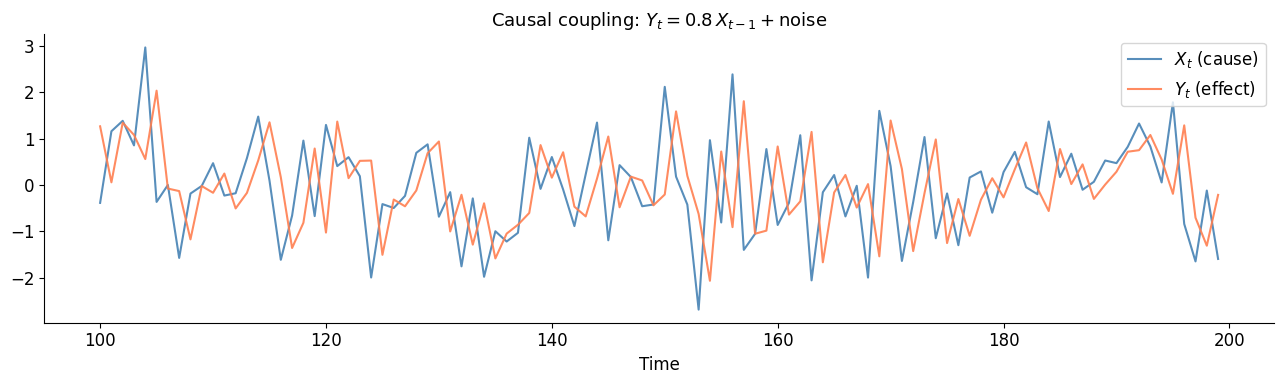

In [11]:
T = 5000  # time steps

X_cause = np.random.randn(T)
Y_effect = np.zeros(T)
Y_effect[0] = np.random.randn()
for t in range(1, T):
    Y_effect[t] = 0.8 * X_cause[t - 1] + 0.2 * np.random.randn()

# Show a segment of the time series
fig, ax = plt.subplots(figsize=(13, 4))
t_show = slice(100, 200)
ax.plot(np.arange(100, 200), X_cause[t_show], '-', color='steelblue',
        label='$X_t$ (cause)', alpha=0.9, lw=1.5)
ax.plot(np.arange(100, 200), Y_effect[t_show], '-', color='coral',
        label='$Y_t$ (effect)', alpha=0.9, lw=1.5)
ax.set_xlabel('Time')
ax.set_title('Causal coupling: $Y_t = 0.8\\,X_{t-1} + \\mathrm{noise}$', fontsize=13)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'causal_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
te_x_to_y = transfer_entropy(source=X_cause, target=Y_effect, k=1, lag=1)
te_y_to_x = transfer_entropy(source=Y_effect, target=X_cause, k=1, lag=1)

print(f'TE(X → Y) = {te_x_to_y:.4f} nats   ← information flows this way')
print(f'TE(Y → X) = {te_y_to_x:.4f} nats   ← essentially zero')
print(f'\nRatio: TE(X→Y) / |TE(Y→X)| = {abs(te_x_to_y / te_y_to_x) if te_y_to_x != 0 else float("inf"):.1f}×')

TE(X → Y) = 1.4255 nats   ← information flows this way
TE(Y → X) = 0.0245 nats   ← essentially zero

Ratio: TE(X→Y) / |TE(Y→X)| = 58.2×


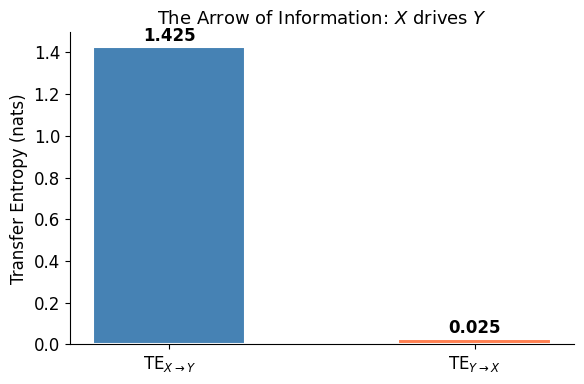

In [13]:
# Visualize the asymmetry
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['$\\mathrm{TE}_{X \\to Y}$', '$\\mathrm{TE}_{Y \\to X}$'],
    [te_x_to_y, max(te_y_to_x, 0)],  # clip negative estimation noise
    color=['steelblue', 'coral'],
    edgecolor='white', linewidth=1.5, width=0.5,
)
ax.set_ylabel('Transfer Entropy (nats)')
ax.set_title('The Arrow of Information: $X$ drives $Y$', fontsize=13)
for bar, val in zip(bars, [te_x_to_y, te_y_to_x]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'transfer_entropy_arrow.png', dpi=150, bbox_inches='tight')
plt.show()

The asymmetry is striking. Transfer entropy detects the causal arrow with high confidence.

### Experiment 2: Independent time series (no information flow)

In [14]:
X_noise = np.random.randn(T)
Y_noise = np.random.randn(T)

te_noise_xy = transfer_entropy(source=X_noise, target=Y_noise)
te_noise_yx = transfer_entropy(source=Y_noise, target=X_noise)

print(f'TE(X → Y) = {te_noise_xy:.4f} nats   ← near zero')
print(f'TE(Y → X) = {te_noise_yx:.4f} nats   ← near zero')
print(f'\nNo causal structure → no information transfer in either direction.')

TE(X → Y) = 0.0064 nats   ← near zero
TE(Y → X) = -0.0092 nats   ← near zero

No causal structure → no information transfer in either direction.


### Experiment 3: Symmetric coupling (bidirectional flow)

What if both variables influence each other equally?

$$
X_t = 0.5\,Y_{t-1} + 0.5\,\varepsilon^X_t, \qquad Y_t = 0.5\,X_{t-1} + 0.5\,\varepsilon^Y_t
$$

In [15]:
X_sym = np.zeros(T)
Y_sym = np.zeros(T)
X_sym[0] = np.random.randn()
Y_sym[0] = np.random.randn()

for t in range(1, T):
    X_sym[t] = 0.5 * Y_sym[t - 1] + 0.5 * np.random.randn()
    Y_sym[t] = 0.5 * X_sym[t - 1] + 0.5 * np.random.randn()

te_sym_xy = transfer_entropy(source=X_sym, target=Y_sym)
te_sym_yx = transfer_entropy(source=Y_sym, target=X_sym)

print(f'TE(X → Y) = {te_sym_xy:.4f} nats')
print(f'TE(Y → X) = {te_sym_yx:.4f} nats')
print(f'\nBoth directions show similar information transfer — symmetric coupling detected.')

TE(X → Y) = 0.1825 nats
TE(Y → X) = 0.1668 nats

Both directions show similar information transfer — symmetric coupling detected.


### A note on Granger causality

Transfer entropy is closely related to **Granger causality** (Clive Granger, 1969 — later a Nobel laureate in economics). Both ask whether the past of $X$ helps predict the future of $Y$ beyond $Y$'s own past. The key difference is that Granger causality assumes a *linear* model, while transfer entropy is fully *nonparametric* — it detects any form of directed statistical dependence, linear or not.

In fact, for jointly Gaussian processes, the two are equivalent (Barnett et al., 2009). Transfer entropy can be seen as the information-theoretic generalization of Granger causality — a fitting example of how Shannon's framework continues to unify and extend classical statistical methods.

### Applications across the sciences

Transfer entropy has found applications in an extraordinary range of fields:

- **Neuroscience:** Mapping directed connectivity between brain regions from EEG/fMRI data
- **Finance:** Detecting information contagion between stock markets during crises
- **Climate science:** Quantifying how El Niño events influence global weather patterns
- **Genomics:** Inferring gene regulatory networks from time-resolved expression data
- **Social networks:** Tracking the flow of influence through online communities

---

## Summary: From Structure to Causality

We have traveled from Watanabe's total correlation (1960) through Meilă's variation of information (2003) to Schreiber's transfer entropy (2000) — a journey across four decades of ideas:

| Measure | Type | Answers | Key property |
|---------|------|---------|-------------|
| **Total Correlation** | Static, multivariate | How much total redundancy among $d$ variables? | Generalizes MI to $d > 2$ |
| **Normalized MI** | Static, pairwise | How much do two variables agree, on a $[0, 1]$ scale? | Comparable across datasets |
| **Variation of Information** | Static, pairwise | How much do two variables disagree? | True metric (triangle inequality) |
| **Transfer Entropy** | Dynamic, directed | Does knowing $X$'s past help predict $Y$'s future? | Detects causal direction |

The common thread is that **information theory provides a universal language for dependence** — whether it is static or dynamic, pairwise or multivariate, symmetric or directed. These measures see structure that correlations miss, and they require no assumptions about the functional form of the relationships.

---

## The Divergence Notebook Series

| # | Notebook | What it covers |
|---|----------|---------------|
| 1 | [Divergence](Divergence.ipynb) | Shannon's foundations: entropy, cross entropy, KL divergence, Jensen-Shannon, mutual information, joint and conditional entropy |
| 2 | [Beyond KL](Beyond_KL.ipynb) | f-divergences (TV, Hellinger, chi-squared, Jeffreys, Cressie-Read) and the Rényi family |
| 3 | [Distances and Testing](Distances_and_Testing.ipynb) | Sample-based methods: Wasserstein, energy distance, MMD, kNN estimators, two-sample permutation tests |
| 4 | **Dependence and Causality** *(this notebook)* | Multivariate dependence (TC, NMI, VI) and directed information flow (transfer entropy) |
| 5 | [Scores and Transport](Scores_and_Transport.ipynb) | The modern frontier: Fisher divergence, kernel Stein discrepancy, Sinkhorn divergence |
| 6 | [Bayesian Diagnostics](Bayesian_Diagnostics.ipynb) | End-to-end MCMC with emcee: convergence diagnostics, information gain, Bayesian surprise |
| 7 | [Real-World Applications](Real_World_Applications.ipynb) | Stock market contagion, crop yields, Phillips Curve — real data, real stakes |